In [ ]:
# Ensure the notebook uses the repository root as its working directory whether launched from notebooks/ or the repository root
import os, sys
from pathlib import Path
ROOT = Path.cwd()
ROOT = ROOT.parent if ROOT.name == "notebooks" else ROOT
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))


# Organizing Experimental Results for Visualization

The following plots are produced:
* Search path for weight [1,1,1], with dark-blue circles for non-STALE points and light-blue × markers for STALE points.
* Non-STALE points for the four weights [1,1,1], (1,0,-1), (0,-1,1), and (-1,1,0), using four distinct high-contrast colors.
* Results after breadth-first search. Some original points may have been erased because they were non-STALE; show only the non-STALE Pareto points in five colors for numerical comparison.

Because each step's results overwrite those from previous steps, the plotting code is embedded between the code for each step rather than placed here; this section is for debugging only (and may not be needed).

In [1]:
import csv
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

database_path = './circuit_database'
ckt_name = 'SMC'

## Search-Path Plotting Function

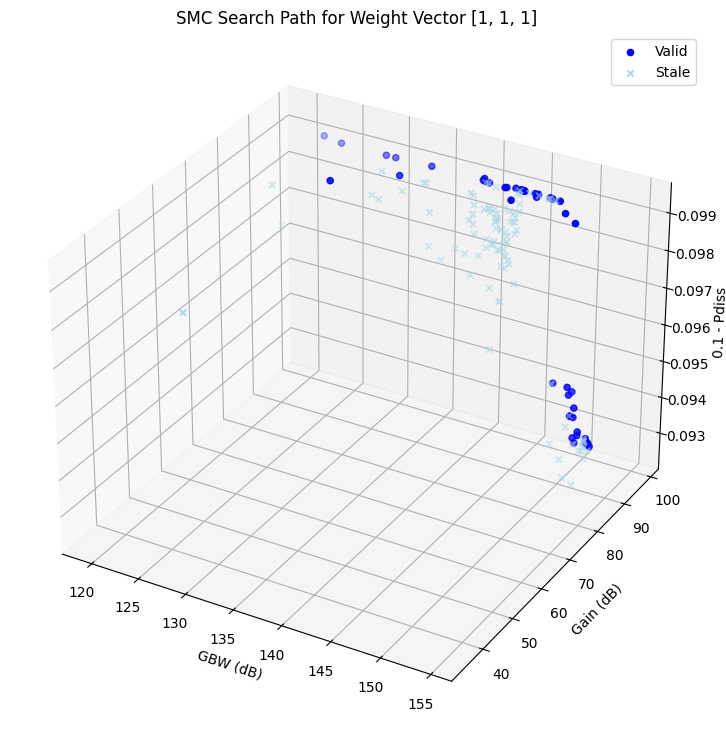

In [2]:
def draw_search_path(csv_path, ckt_name, weight_vector='[1, 1, 1]'):
    '''
    Display the search path for weight_vector: dark-blue circles denote non-STALE points and light-blue × markers denote STALE points
    e.g. [1, 1, 1], as a string
    '''
    
    # Read the CSV file
    # csv_path = f'{database_path}/{ckt_name}/result.csv'
    
    df = pd.read_csv(csv_path)
    
    # Strip whitespace from column names
    df.columns = df.columns.str.strip()
    
    # Select columns to read
    GBW = df['GBW']
    Gain = df['Gain']
    Pdiss = df['Pdiss']
    path = df['solution path']
    weight = df["performance weight"]
    
    # Keep only points with the weight_vector weight
    mask = (weight == weight_vector)
    # Raise an error if all weights are zero
    if mask.sum() == 0:
        raise ValueError(f'No data found for weight vector: {weight_vector}')
    GBW = GBW[mask]
    Gain = Gain[mask]
    Pdiss = Pdiss[mask]
    
    # Group the data
    mask_valid = (path != 'STALE')
    GBW_v, Gain_v, Pdiss_v = GBW[mask_valid], Gain[mask_valid], Pdiss[mask_valid]
    GBW_s, Gain_s, Pdiss_s = GBW[~mask_valid], Gain[~mask_valid], Pdiss[~mask_valid]
    
    # Transform the coordinates
    x_v = 20 * np.log10(GBW_v)          # GBW/dB
    y_v = Gain_v                        # Gain/dB
    z_v = 0.1 - Pdiss_v                 # 0.1 - Pdiss
    
    x_s = 20 * np.log10(GBW_s)
    y_s = Gain_s
    z_s = 0.1 - Pdiss_s
    
    # Plot
    fig = plt.figure(figsize=(9, 9))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(x_v, y_v, z_v, c='blue',  marker='o', label='Valid')
    ax.scatter(x_s, y_s, z_s, c='lightblue',   marker='x', label='Stale')
    
    # Axes and legend
    ax.set_xlabel('GBW (dB)')
    ax.set_ylabel('Gain (dB)')
    ax.set_zlabel('0.1 - Pdiss')
    ax.set_title(f'{ckt_name} Search Path for Weight Vector {weight_vector}')
    ax.legend()
    plt.show()
    
csv_path = f'circuit_database/SMC/result_1_1_1_20250521-123122.csv'
draw_search_path(csv_path, ckt_name)

## Breadth-First Search Visualization

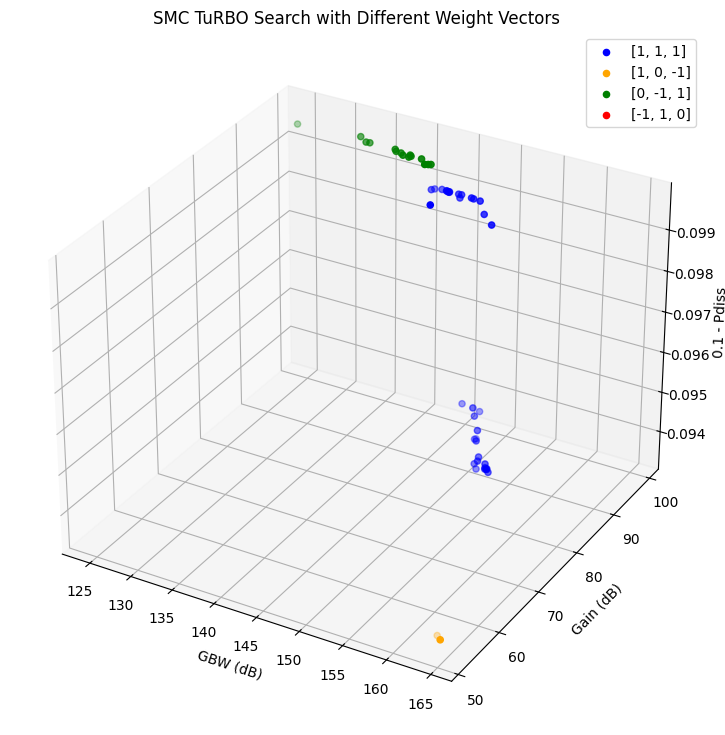

In [3]:
def draw_pareto_TuRBO(csv_path, ckt_name, weight_vectors=['[1, 1, 1]', '[1, 0, -1]', '[0, -1, 1]', '[-1, 1, 0]'], STALE=False):
    '''
    Display non-STALE points for the four weights [1,1,1], (1,0,-1), (0,-1,1), and (-1,1,0), using four distinct high-contrast colors
    STALE=False means keep only non-STALE points
    '''
    
    # Read the CSV file
    # csv_path = f'{database_path}/{ckt_name}/result.csv'
    
    df = pd.read_csv(csv_path)
    
    # Strip whitespace from column names
    df.columns = df.columns.str.strip()
    
    # Select columns to read
    GBW = df['GBW']
    Gain = df['Gain']
    Pdiss = df['Pdiss']
    path = df['solution path']
    weight = df["performance weight"]
    
    if STALE==False:
        # Keep only non-STALE points
        mask = (path != 'STALE')
        GBW = GBW[mask]
        Gain = Gain[mask]
        Pdiss = Pdiss[mask]
    
    # Group by weight
    GBW_list = []
    Gain_list = []
    Pdiss_list = []
    for weight_vector in weight_vectors:
        mask = (weight == weight_vector)
        # # Raise an error if all weights are zero
        # if mask.sum() == 0:
        #     raise ValueError(f'No data found for weight vector: {weight_vector}')
        GBW_list.append(GBW[mask])
        Gain_list.append(Gain[mask])
        Pdiss_list.append(Pdiss[mask])
        
    # Plot each group
    fig = plt.figure(figsize=(9, 9))
    ax = fig.add_subplot(111, projection='3d')
    colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown']
    for i in range(len(weight_vectors)):
        GBW = GBW_list[i]
        Gain = Gain_list[i]
        Pdiss = Pdiss_list[i]
        weight = weight_vectors[i]
        
        color = colors[i % len(colors)]
        
        x = 20 * np.log10(GBW)          # GBW/dB
        y = Gain                        # Gain/dB
        z = 0.1 - Pdiss                 # 0.1 - Pdiss
        
        ax.scatter(x, y, z, c=color,  marker='o', label=weight)
    

    # Axes and legend
    ax.set_xlabel('GBW (dB)')
    ax.set_ylabel('Gain (dB)')
    ax.set_zlabel('0.1 - Pdiss')
    ax.set_title(f'{ckt_name} TuRBO Search with Different Weight Vectors')
    ax.legend()
    plt.show()
    
csv_path = f'circuit_database/SMC/result_20250521-132544_allweights.csv'
draw_pareto_TuRBO(csv_path, "SMC", STALE=False)

## Depth-First Search Visualization

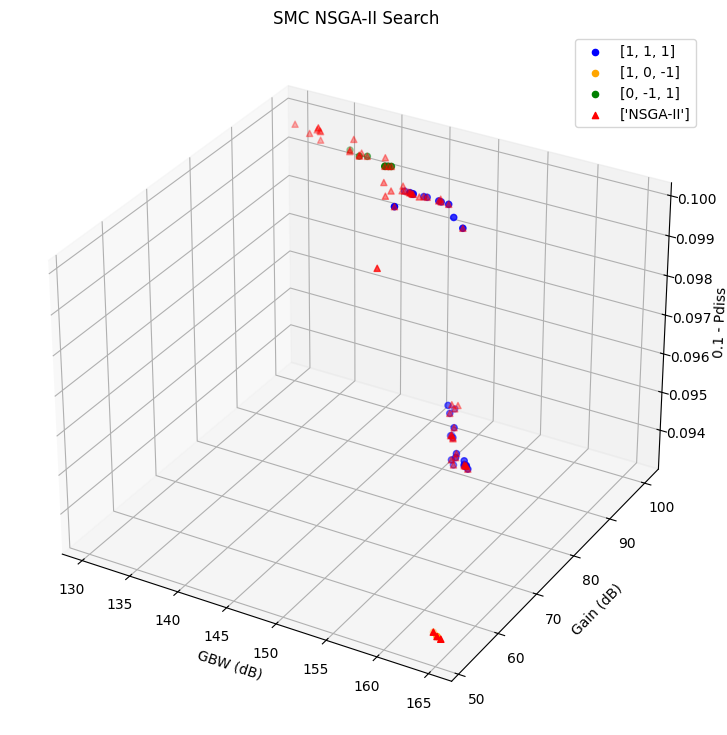

In [12]:
def draw_pareto_NSGA2(csv_path, ckt_name, weight_vectors=None, STALE=False):
    '''
    Display the results after breadth-first search. Some original points may have been erased because they were non-STALE; show only non-STALE Pareto points in five colors for numerical comparison
    
    By default, use all weights and add ['NSGA-II']; if weight is None, use every weight
    '''
    
    # Read the CSV file
    # csv_path = f'{database_path}/{ckt_name}/result.csv'
    
    df = pd.read_csv(csv_path)
    
    # Strip whitespace from column names
    df.columns = df.columns.str.strip()
    
    # Select columns to read
    GBW = df['GBW']
    Gain = df['Gain']
    Pdiss = df['Pdiss']
    path = df['solution path']
    weight = df["performance weight"]
    
    # Determine which weights to plot
    if weight_vectors is None:
        # Use all weights appearing in df["performance weight"]
        weight_vectors = df["performance weight"].unique()
    else:
        if "['NSGA-II']" not in weight_vectors:
            weight_vectors.append("['NSGA-II']")
    
    if STALE==False:
        # Keep only non-STALE points
        mask = (path != 'STALE')
        GBW = GBW[mask]
        Gain = Gain[mask]
        Pdiss = Pdiss[mask]
    
    # Group by weight
    GBW_list = []
    Gain_list = []
    Pdiss_list = []
    for weight_vector in weight_vectors:
        mask = (weight == weight_vector)
        # # Raise an error if all weights are zero
        # if mask.sum() == 0:
        #     raise ValueError(f'No data found for weight vector: {weight_vector}')
        GBW_list.append(GBW[mask])
        Gain_list.append(Gain[mask])
        Pdiss_list.append(Pdiss[mask])
        
    # Plot each group
    fig = plt.figure(figsize=(9, 9))
    ax = fig.add_subplot(111, projection='3d')
    colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown']
    for i in range(len(weight_vectors)):
        GBW = GBW_list[i]
        Gain = Gain_list[i]
        Pdiss = Pdiss_list[i]
        weight = weight_vectors[i]
        
        color = colors[i % len(colors)]
        
        x = 20 * np.log10(GBW)          # GBW/dB
        y = Gain                        # Gain/dB
        z = 0.1 - Pdiss                 # 0.1 - Pdiss
        
        # Use a different marker when weight is NSGA-II
        if weight == "['NSGA-II']":
            ax.scatter(x, y, z, c=color,  marker='^', label=weight)
        else:
            ax.scatter(x, y, z, c=color,  marker='o', label=weight)

    # Axes and legend
    ax.set_xlabel('GBW (dB)')
    ax.set_ylabel('Gain (dB)')
    ax.set_zlabel('0.1 - Pdiss')
    ax.set_title(f'{ckt_name} NSGA-II Search')
    ax.legend()
    plt.show()
    
csv_path = f'circuit_database/SMC/result_20250521-235404_allweights_nsga2.csv'
# draw_pareto_NSGA2(csv_path, "SMC", weight_vectors=["[4, 0, 1]"], STALE=False)
draw_pareto_NSGA2(csv_path, "SMC", None, False)

## Visualizing All Circuits

Three plots in total: search paths; all points for [1,1,1]; non-STALE points from result_20250521; and non-STALE points from result.

### SMC

csv1: ./circuit_database/SMC/result_1_1_1_20250521-123122.csv csv2: ./circuit_database/SMC/result_20250521-132544_allweights.csv csv3: ./circuit_database/SMC/result_20250522-022232_allweights_nsga2.csv


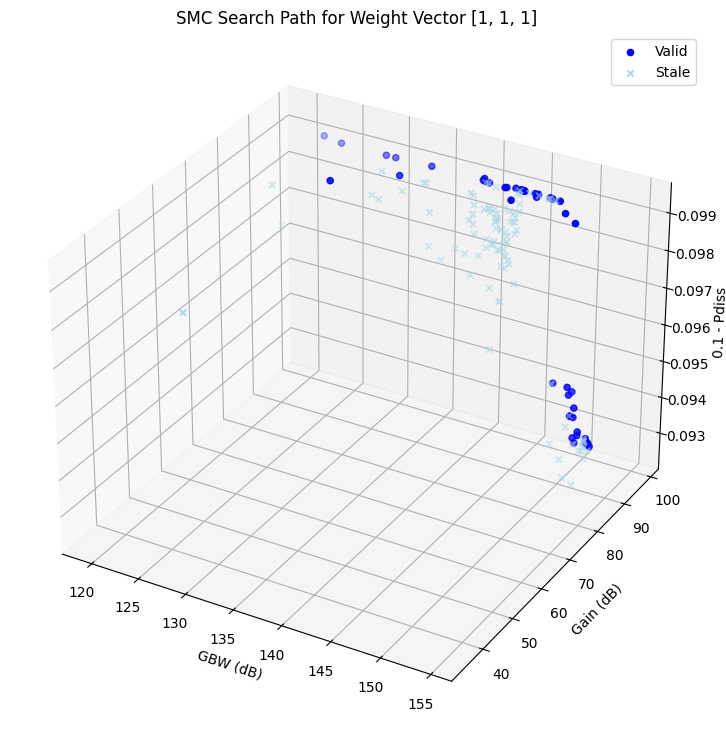

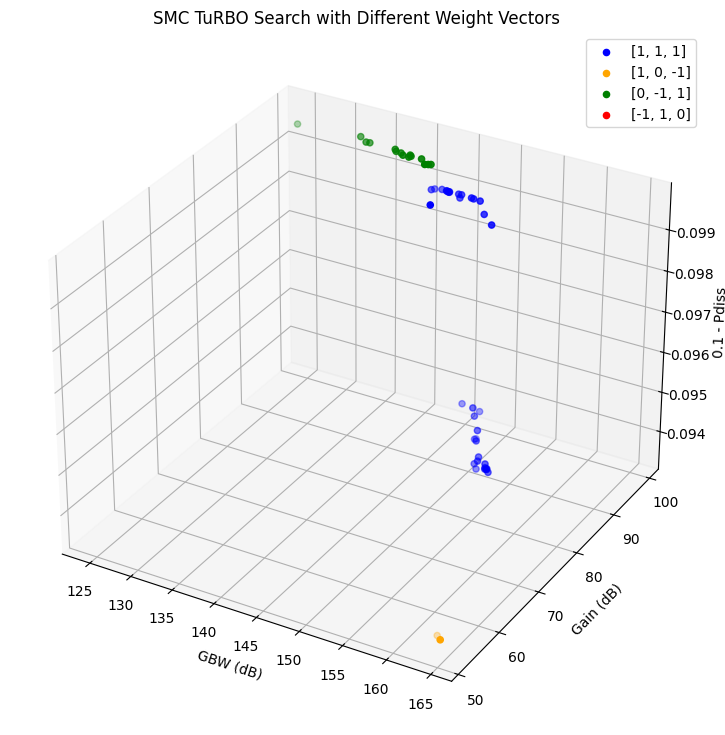

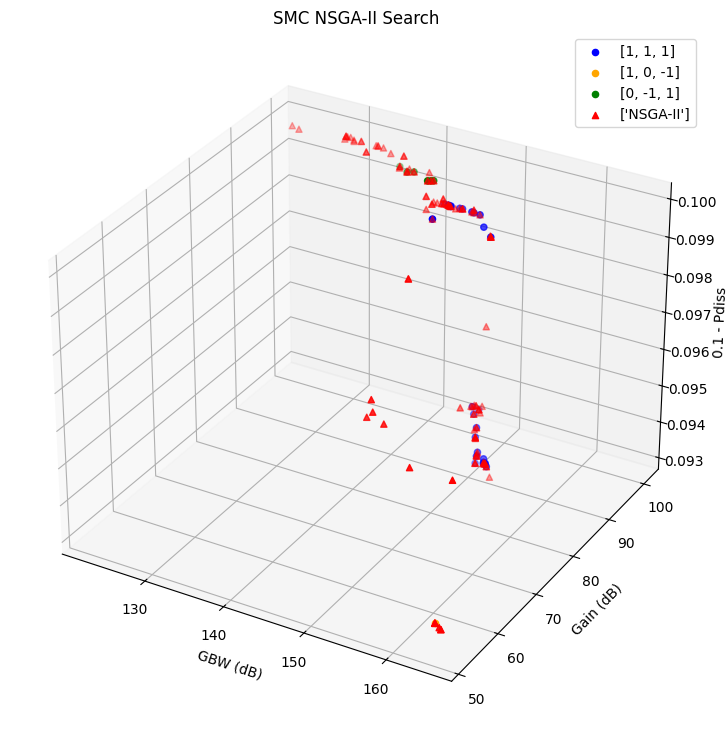

In [5]:
import os

ckt_name = 'SMC'
database_path = './circuit_database'
csv_folder_path = f'{database_path}/{ckt_name}'

# Match the target CSV files in folder
csv1 = None
csv2 = None
csv3 = None
for file in os.listdir(csv_folder_path):
    if file.endswith('.csv'):
        # Match files starting with "result_1_1_1"
        if file.startswith('result_1_1_1'):
            csv1 = os.path.join(csv_folder_path, file)
        # Match files ending with allweights.csv
        elif file.endswith('allweights.csv'):
            csv2 = os.path.join(csv_folder_path, file)
        # Match files ending with nsga2.csv
        elif file.endswith('nsga2.csv'):
            csv3 = os.path.join(csv_folder_path, file)
        else:
            continue
    else:
        continue

print(f"csv1: {csv1}", f"csv2: {csv2}", f"csv3: {csv3}")
# Plot
draw_search_path(csv1, ckt_name)
draw_pareto_TuRBO(csv2, ckt_name)
draw_pareto_NSGA2(csv3, ckt_name)

### Other Circuits

csv1: ./circuit_database/NMCNR/result_1_1_1_20250521-151738.csv csv2: ./circuit_database/NMCNR/result_20250521-155605_allweights.csv csv3: ./circuit_database/NMCNR/result_20250522-000246_allweights_nsga2.csv


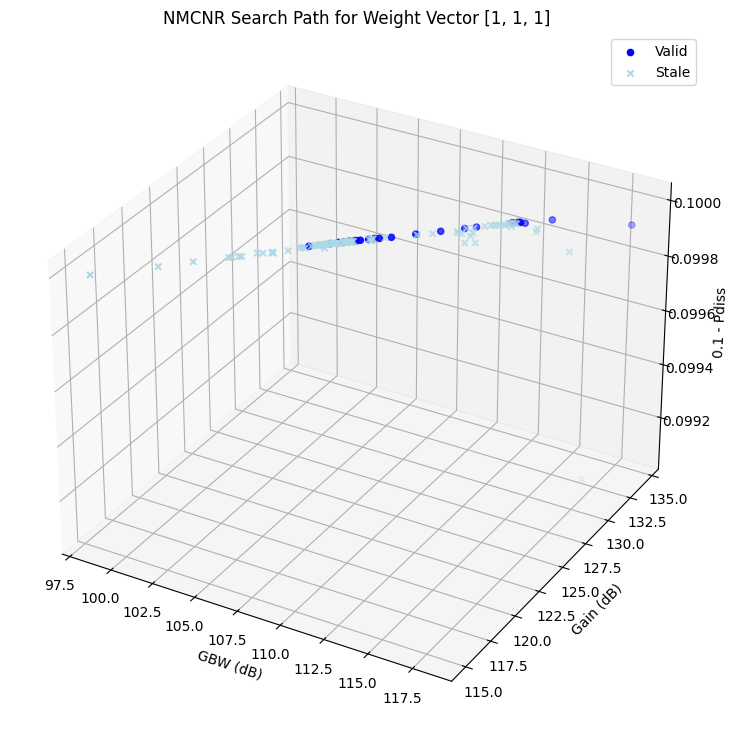

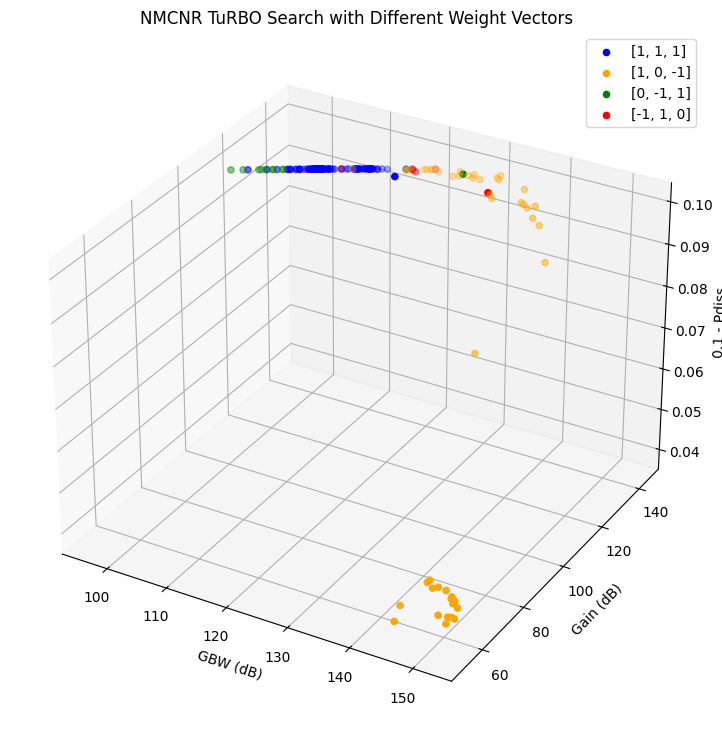

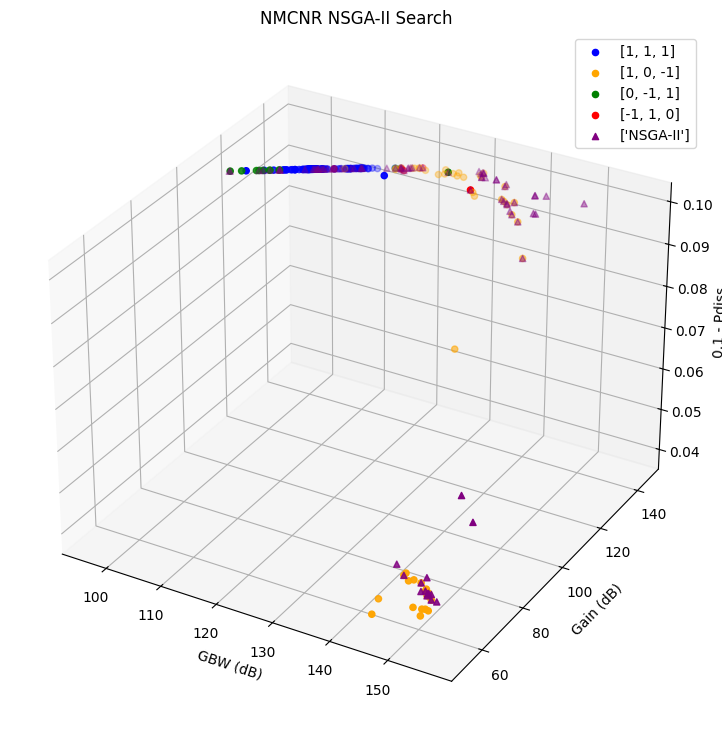

csv1: ./circuit_database/DFCFC1/result_1_1_1_20250521-162147.csv csv2: ./circuit_database/DFCFC1/result_20250521-173305_allweights.csv csv3: ./circuit_database/DFCFC1/result_20250522-001659_allweights_nsga2.csv


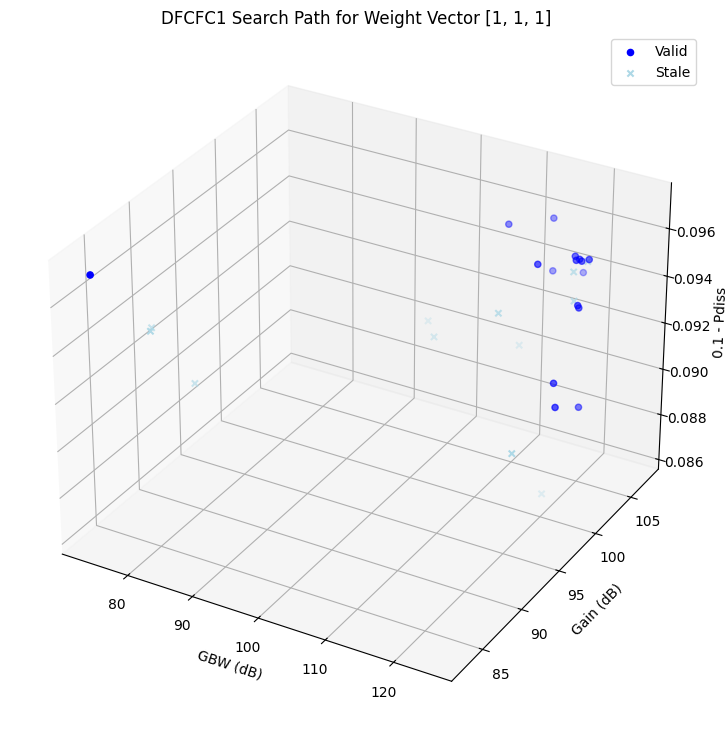

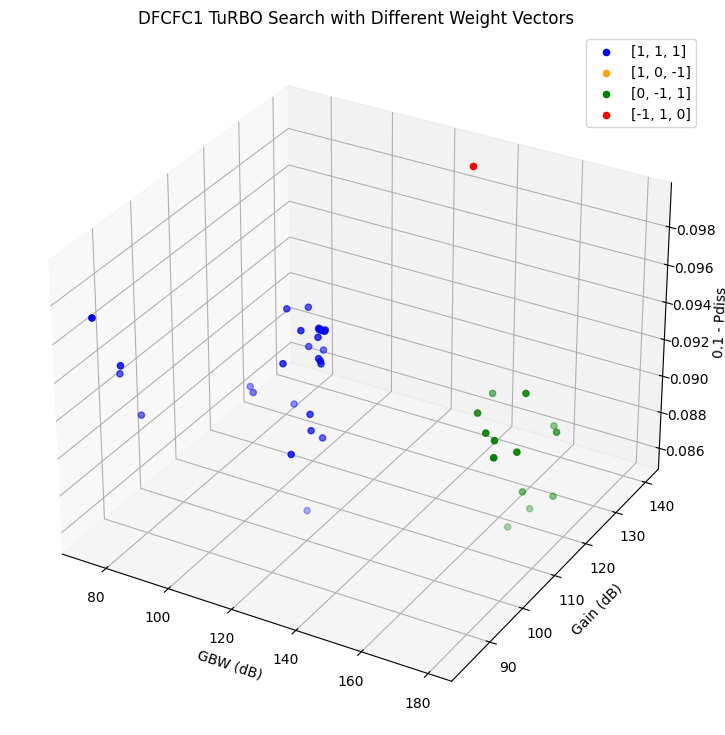

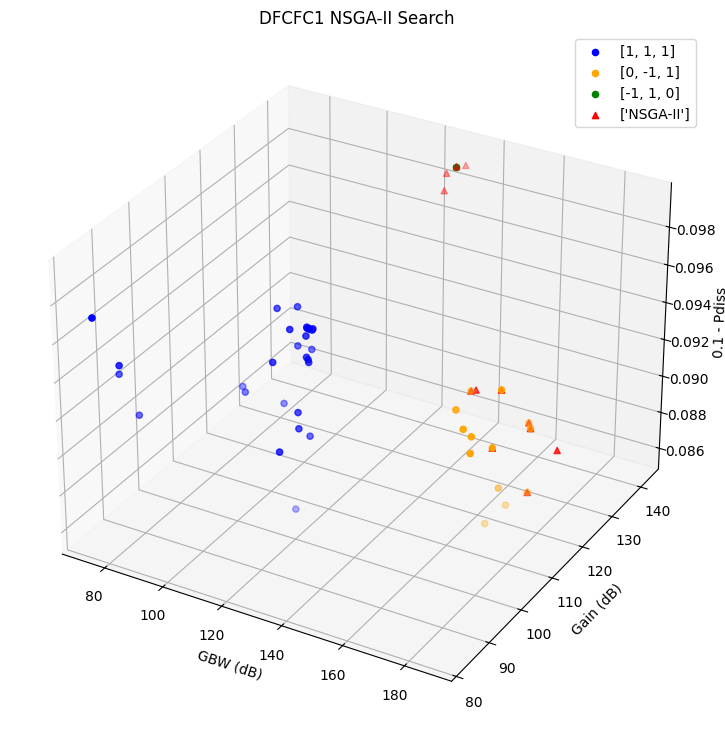

csv1: ./circuit_database/NGCC/result_1_1_1_20250521-180233.csv csv2: ./circuit_database/NGCC/result_20250521-194955_allweights.csv csv3: ./circuit_database/NGCC/result_20250522-003212_allweights_nsga2.csv


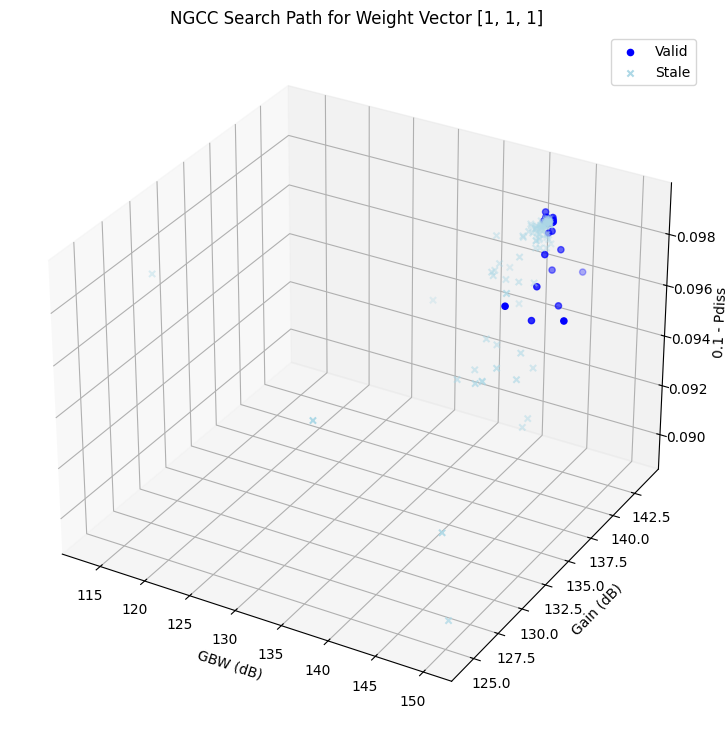

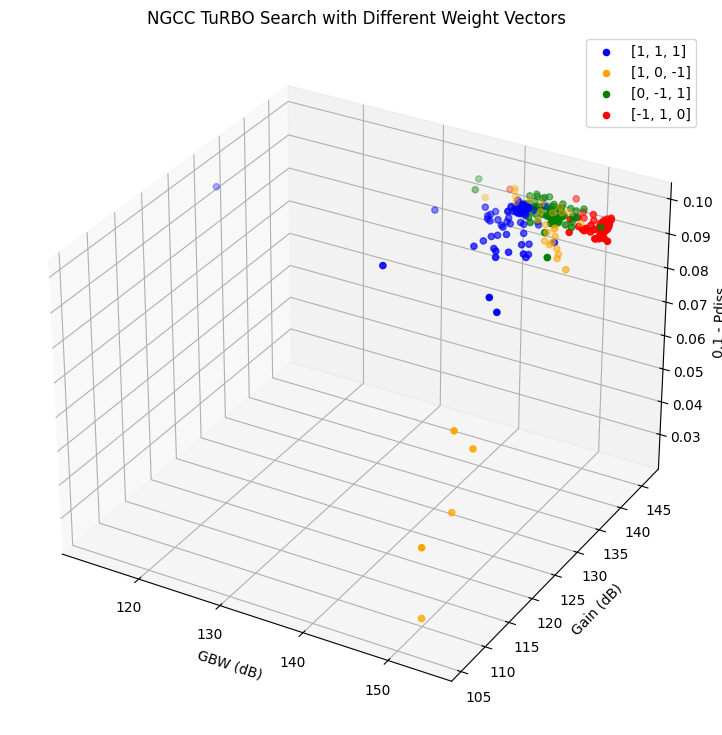

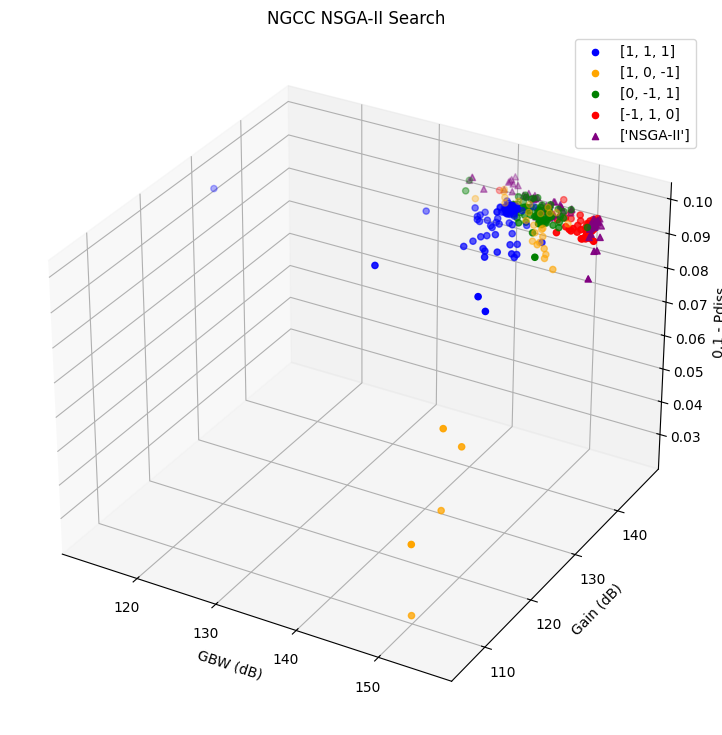

csv1: ./circuit_database/TCFC/result_1_1_1_20250521-200830.csv csv2: ./circuit_database/TCFC/result_20250521-211419_allweights.csv csv3: ./circuit_database/TCFC/result_20250522-004034_allweights_nsga2.csv


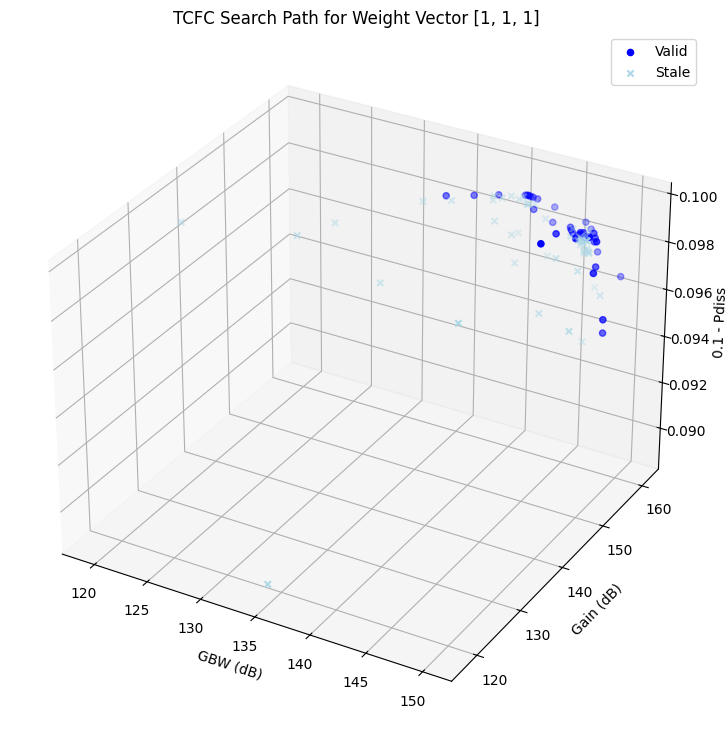

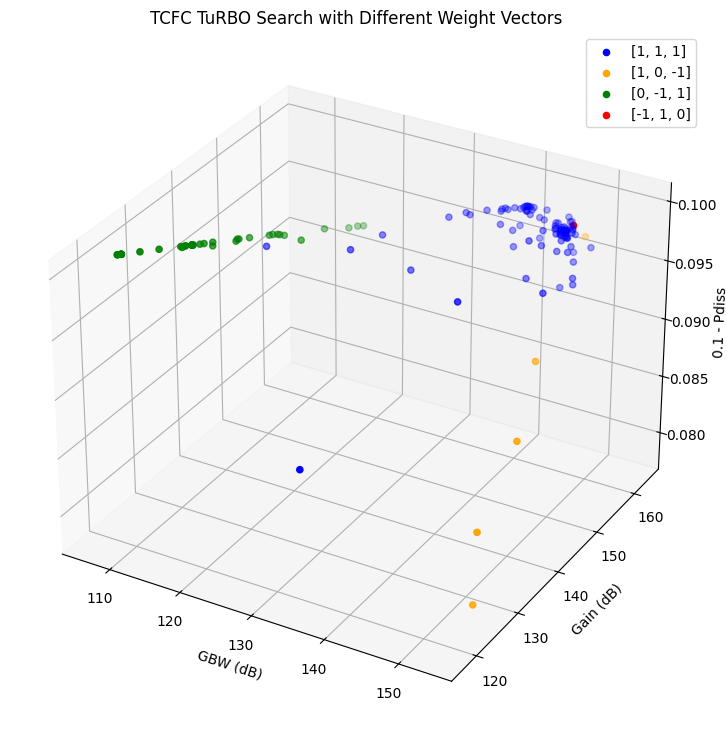

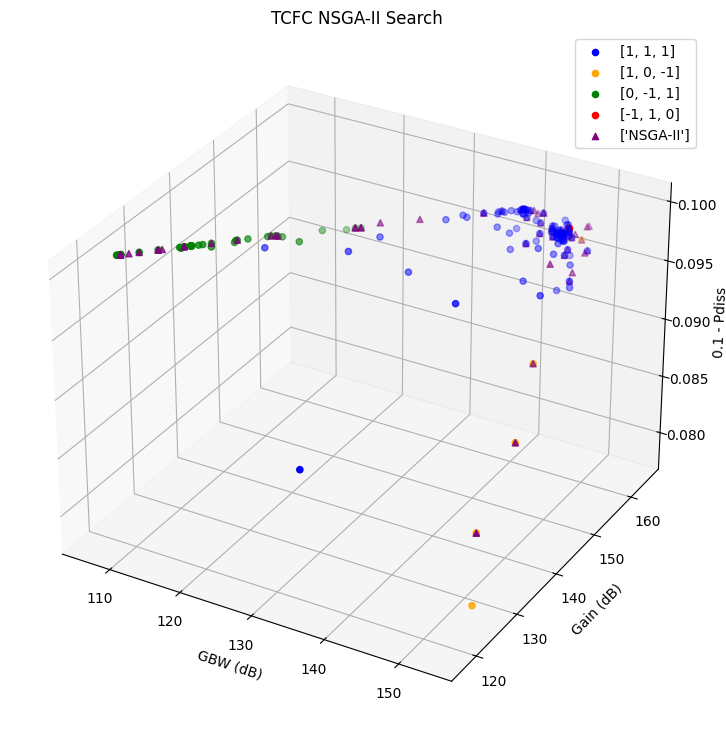

csv1: ./circuit_database/AZC/result_1_1_1_20250521-213511.csv csv2: ./circuit_database/AZC/result_20250521-223039_allweights.csv csv3: ./circuit_database/AZC/result_20250522-005016_allweights_nsga2.csv


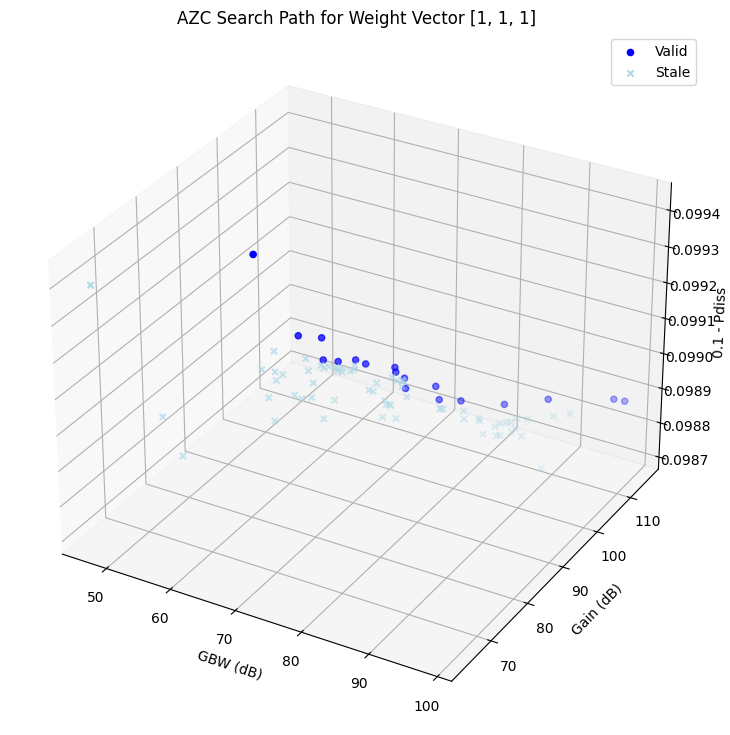

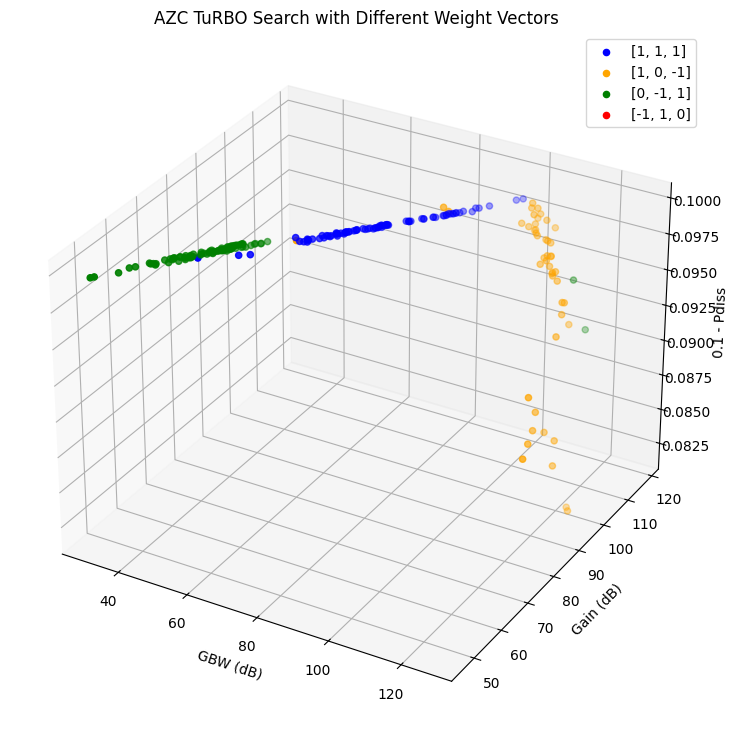

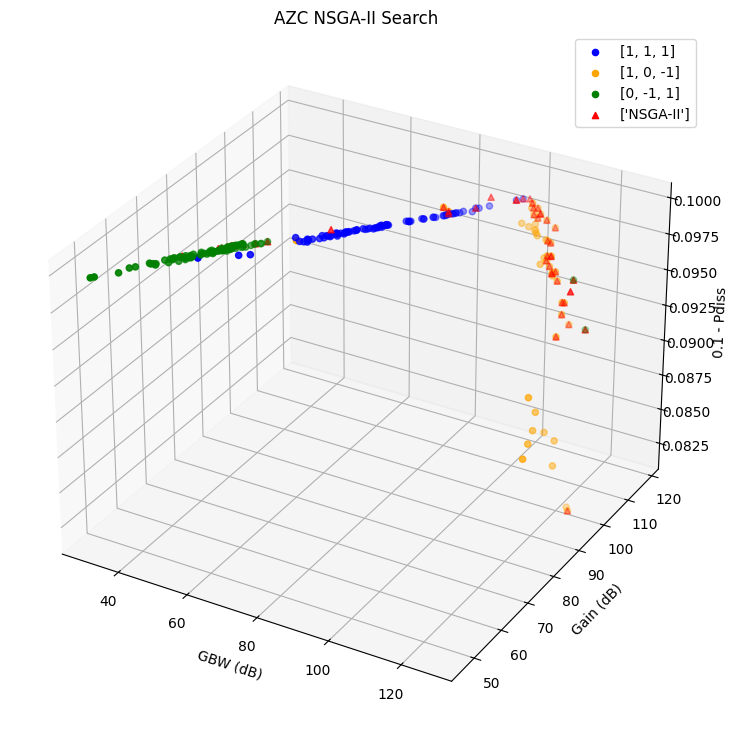

csv1: ./circuit_database/IAC/result_1_1_1_20250521-224520.csv csv2: ./circuit_database/IAC/result_20250521-232905_allweights.csv csv3: ./circuit_database/IAC/result_20250522-005729_allweights_nsga2.csv


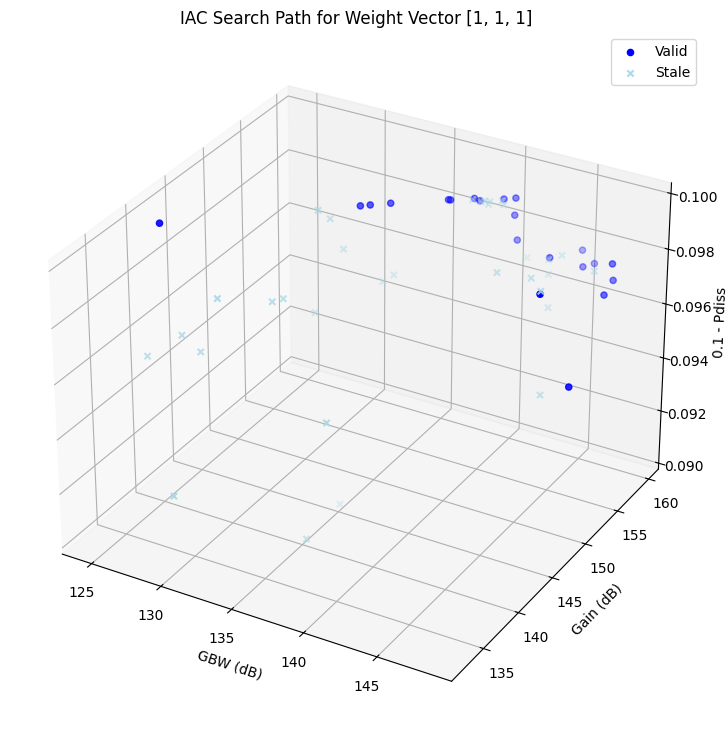

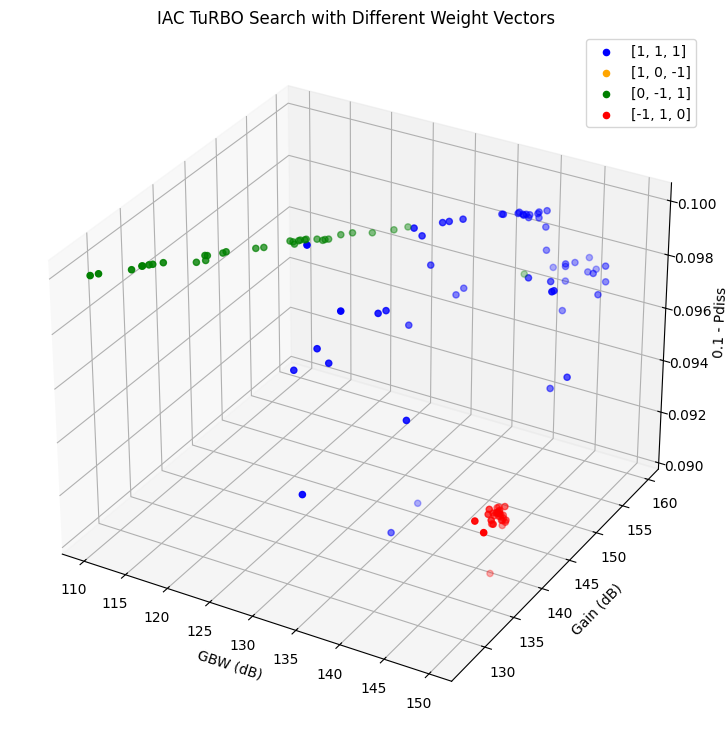

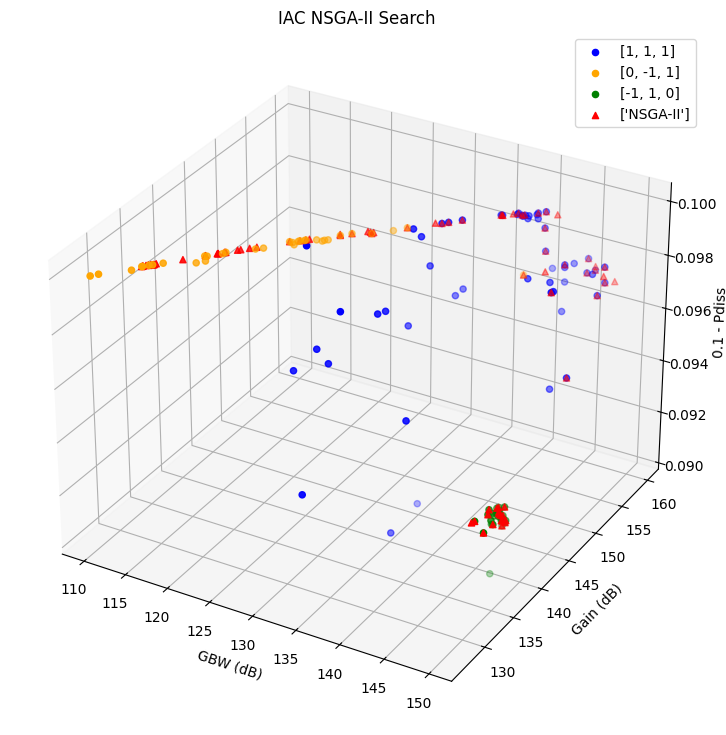

In [6]:
ckt_lists = ['NMCNR', 'DFCFC1', 'NGCC', 'TCFC', 'AZC', 'IAC'] 

for ckt_name in ckt_lists:

    database_path = './circuit_database'
    csv_folder_path = f'{database_path}/{ckt_name}'

    # Match the target CSV files in folder
    csv1 = None
    csv2 = None
    csv3 = None
    for file in os.listdir(csv_folder_path):
        if file.endswith('.csv'):
            # Match files starting with "result_1_1_1"
            if file.startswith('result_1_1_1'):
                csv1 = os.path.join(csv_folder_path, file)
            # Match files ending with allweights.csv
            elif file.endswith('allweights.csv'):
                csv2 = os.path.join(csv_folder_path, file)
            # Match files ending with nsga2.csv
            elif file.endswith('nsga2.csv'):
                csv3 = os.path.join(csv_folder_path, file)
            else:
                continue
        else:
            continue

    print(f"csv1: {csv1}", f"csv2: {csv2}", f"csv3: {csv3}")
    # Plot
    draw_search_path(csv1, ckt_name)
    draw_pareto_TuRBO(csv2, ckt_name, STALE=True)
    draw_pareto_NSGA2(csv3, ckt_name, STALE=True)

In [ ]:
# Count Pareto and non-Pareto points in the CSV
# circuit_database/SMC/result_20250521-132544_allweights.csv
# circuit_database/SMC/result_20250521-235404_allweights_nsga2.csv
# circuit_database/SMC/result_20250522-022232_allweights_nsga2.csv

# csv1: ./circuit_database/IAC/result_1_1_1_20250521-224520.csv csv2: ./circuit_database/IAC/result_20250521-232905_allweights.csv csv3: ./circuit_database/IAC/result_20250522-005729_allweights_nsga2.csv
import pandas as pd


csv_path = "./circuit_database/IAC/result_20250522-005729_allweights_nsga2.csv"

df = pd.read_csv(csv_path)
# Strip whitespace from column names
df.columns = df.columns.str.strip()
# Select columns to read
path = df['solution path']
# Keep only non-STALE points
mask = (path != 'STALE')
# Count the total and non-STALE points
total_count = len(df)
valid_count = len(df[mask])
print(f"Total count: {total_count}")
print(f"Valid count: {valid_count}")

# IAC_all_weights: 117, 50
# 204, 99

Total count: 204
Valid count: 99


## Plotting All Circuits Together